In [1]:
import librosa
import os
import pandas as pd
import sys
import numpy as np
from pathlib import Path
import pickle
ROOT = Path("..") if Path("../configs").exists() else Path(".")
sys.path.append(os.path.abspath("algorithm"))
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT))
from src.hcm_transcription.utils import normalize_target_label, TARGET_LABELS, df_to_anno

In [2]:
label_folder = r"..\data\DATA\ROD\Expert_002\labels\train"  # adjust path

all_labels = set()
for f in os.listdir(label_folder):
    if f.endswith(".txt"):
        df = pd.read_csv(os.path.join(label_folder, f), sep="\t", header=None,
                         names=["time_s", "time_e", "label"])
        all_labels.update(df["label"].dropna().unique())

print(sorted(all_labels))

['An', 'G', 'H', 'H ', 'H  ', 'K', 'K ', 'M', 'Me', 'Me  ', 'Me1', 'Mu']


In [ ]:
def extract_rod_segments(audio_dir, labels_dir, cache_path="rod_segments.pkl", min_length=20, force_recompute=False):
   
    # If already computed, just load
    if os.path.exists(cache_path) and not force_recompute:
        print(f"Loading cached segments from {cache_path}...")
        with open(cache_path, "rb") as f:
            return pickle.load(f)
    
    print("No cache found (or force_recompute=True). Extracting from scratch...")
    segments = []
    skipped_labels = set()

    # Walk through both experts and both splits
    for expert in ["Expert_002\labels", "Expert_001\labels"]:
        for split in ["train", "test"]:
            label_folder = os.path.join(labels_dir, expert, split)
            if not os.path.exists(label_folder):
                print(f"WARNING: {label_folder} not found, skipping")
                continue

            for label_file in os.listdir(label_folder):
                if not label_file.endswith(".txt"):
                    continue

                # Match audio file by same name
                song_name = os.path.splitext(label_file)[0]
                audio_path = os.path.join(audio_dir, f"{song_name}.wav")
                label_path = os.path.join(label_folder, label_file)

                if not os.path.exists(audio_path):
                    print(f"  WARNING: audio not found for {song_name}, skipping")
                    continue

                print(f"Loading {song_name} ({expert}, {split})...")

                # Load annotations
                df_anno = pd.read_csv(label_path, sep="\t", header=None,
                                      names=["time_s", "time_e", "label"])
                df_anno["duration"] = df_anno["time_e"] - df_anno["time_s"]

                # Track skipped labels
                skipped_labels.update(
                    label for label in df_anno["label"].dropna().unique()
                    if normalize_target_label(label) is None
                )

                # Remap labels
                df_anno["label"] = df_anno["label"].map(normalize_target_label)
                df_anno = df_anno[df_anno["label"].isin(TARGET_LABELS)].reset_index(drop=True)
                print(f"  Found {len(df_anno)} target ornaments")

                if len(df_anno) == 0:
                    continue

                # Extract pitch curve from audio using librosa
                y, sr = librosa.load(audio_path, sr=None)

                # Extract f0 using librosa's yin
                f0 = librosa.yin( #add f0, voiced_flag, _ =... for pyin
                    y, sr=sr,
                    fmin=librosa.note_to_hz('C2'),
                    fmax=librosa.note_to_hz('C7'),
                    hop_length=256
                )

                # Build time array
                times = librosa.times_like(f0, sr=sr, hop_length=256)

                # Convert to log f0
                log_f0 = np.where(f0 > 0, np.log2(f0), np.nan)

                # Build pitch dataframe
                df_pitch = pd.DataFrame({"time": times, "log_f0": log_f0})

                # Extract segments
                for _, row in df_anno.iterrows():
                    mask = (df_pitch["time"] >= row['time_s']) & \
                           (df_pitch["time"] <= row['time_e'])
                    segment_pitch = df_pitch[mask]["log_f0"].values

                    if len(segment_pitch) < min_length:
                        continue
                    if np.isnan(segment_pitch).mean() > 0.3:
                        continue

                    segment_pitch = pd.Series(segment_pitch).interpolate().fillna(0).values

                    segments.append({
                        "song": song_name,
                        "expert": expert,
                        "split": split,
                        "label": row['label'],
                        "time_s": row['time_s'],
                        "time_e": row['time_e'],
                        "duration": row['duration'],
                        "pitch_curve": segment_pitch
                    })
    
    print(f"Extracted {len(segments)} segments. Saving cache...")

    with open(cache_path, "wb") as f:
        pickle.dump(segments, f)

    print(f"Saved to {cache_path}")

    # Summary
    df_segments = pd.DataFrame([{k: v for k, v in s.items() if k != "pitch_curve"}
                                  for s in segments])
    print(f"\n=== ROD Extraction Summary ===")
    print(f"Total segments: {len(segments)}")
    if not df_segments.empty:
        print(f"Label distribution:\n{df_segments['label'].value_counts()}")
        print(f"Expert distribution:\n{df_segments['expert'].value_counts()}")
        print(f"Duration stats:\n{df_segments['duration'].describe()}")
    print(f"Skipped ornament types: {sorted(skipped_labels)}")

    return segments

In [4]:
audio_dir  = r"..\data\DATA\ROD\audio"
labels_dir = r"..\data\DATA\ROD"

segments = extract_rod_segments(audio_dir, labels_dir)

No cache found (or force_recompute=True). Extracting from scratch...
Loading 002_bhairav10_Bandish sthai whole bol (Expert_002\labels, train)...
  Found 14 target ornaments
Loading 002_bhairav10_Bhairav_Basic_PALTA 5_Ekgun_Aakar (Expert_002\labels, train)...
  Found 5 target ornaments
Loading 002_bhairav11_Bandish antara-1 bol (Expert_002\labels, train)...
  Found 8 target ornaments
Loading 002_bhairav11_Bhairav_Palta_3_Dogun_Swara (Expert_002\labels, train)...
  Found 0 target ornaments
Loading 002_bhairav12_Bandish antara- 2 bol (Expert_002\labels, train)...
  Found 8 target ornaments
Loading 002_bhairav12_Bhairav_Palta_3_Dogun_Aakar (Expert_002\labels, train)...
  Found 0 target ornaments
Loading 002_bhairav13_Bandish antara whole bol (Expert_002\labels, train)...
  Found 15 target ornaments
Loading 002_bhairav14_Bandish sthai antara whole bol (Expert_002\labels, train)...
  Found 28 target ornaments
Loading 002_bhairav15_Bhairav_Palta_4_Dogun_Swara (Expert_002\labels, train)...
  F

### Data inspection

In [5]:
segments[0].keys()

dict_keys(['song', 'expert', 'split', 'label', 'time_s', 'time_e', 'duration', 'pitch_curve'])

In [6]:
from collections import Counter

# Load cached segments
with open("rod_segments.pkl", "rb") as f:
    segments = pickle.load(f)

# Count ornament labels
labels = [s["label"] for s in segments]

label_counts = Counter(labels)

print("Available ornament types:\n")

for label, count in sorted(label_counts.items()):    print(f"{label}: {count}")

Available ornament types:

Andolan: 47
Kan: 991
Meend: 1079
Murki: 171


Loaded 2288 segments


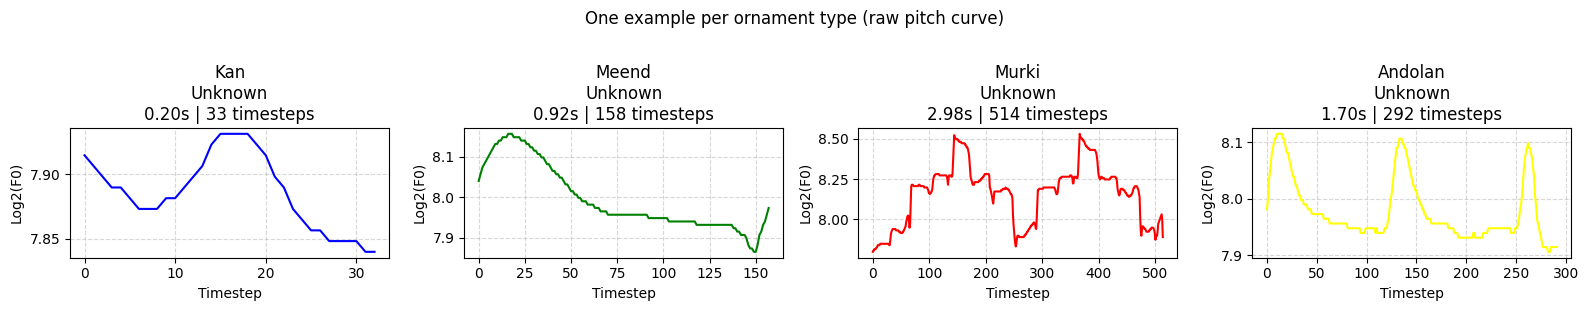

In [8]:
import matplotlib.pyplot as plt

# Load cached segments
with open("rod_segments.pkl", "rb") as f:
    segments = pickle.load(f)

print(f"Loaded {len(segments)} segments")

# Plot one example per class
fig, axes = plt.subplots(1, 4, figsize=(16, 3))

colors = {
    "Kan": "blue",
    "Meend": "green",
    "Murki": "red",
    "Andolan": "yellow"
}

for ax, label in zip(axes, ["Kan", "Meend", "Murki", "Andolan"]):

    # Find first example of this label
    example = next((s for s in segments if s['label'] == label), None)

    if example is None:
        ax.set_title(f"{label}\n(not found)")
        continue

    curve = example['pitch_curve']

    ax.plot(curve, color=colors[label], linewidth=1.5)

    # Some datasets may not contain raga metadata
    raga = example.get("raga", "Unknown")

    ax.set_title(
        f"{label}\n"
        f"{raga}\n"
        f"{example['duration']:.2f}s | {len(curve)} timesteps"
    )

    ax.set_xlabel("Timestep")
    ax.set_ylabel("Log2(F0)")
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle("One example per ornament type (raw pitch curve)", y=1.02)

plt.tight_layout()
plt.show()

In [9]:
# Build summary dataframe
df_segments = pd.DataFrame([{k: v for k, v in s.items() if k != "pitch_curve"} for s in segments])
df_segments['num_timesteps'] = [len(s['pitch_curve']) for s in segments]

print("=== Class Distribution ===")
print(df_segments['label'].value_counts())

print("\n=== Duration Stats per Class (seconds) ===")
print(df_segments.groupby('label')['duration'].describe().round(3))

print("\n=== Timestep Stats per Class ===")
print(df_segments.groupby('label')['num_timesteps'].describe().round(1))


=== Class Distribution ===
label
Meend      1079
Kan         991
Murki       171
Andolan      47
Name: count, dtype: int64

=== Duration Stats per Class (seconds) ===
          count   mean    std    min    25%    50%    75%     max
label                                                            
Andolan    47.0  3.101  1.332  1.444  2.226  2.585  4.175   6.177
Kan       991.0  0.256  0.062  0.124  0.213  0.247  0.286   0.517
Meend    1079.0  0.586  0.197  0.288  0.470  0.530  0.623   1.788
Murki     171.0  2.143  2.521  0.334  0.502  1.115  2.935  17.876

=== Timestep Stats per Class ===
          count   mean    std    min    25%    50%    75%     max
label                                                            
Andolan    47.0  534.1  229.4  249.0  384.0  445.0  719.5  1064.0
Kan       991.0   44.2   10.7   21.0   37.0   43.0   49.0    89.0
Meend    1079.0  101.0   33.9   50.0   81.0   91.0  107.0   308.0
Murki     171.0  380.0  458.4   57.0   86.5  192.0  527.0  3079.0


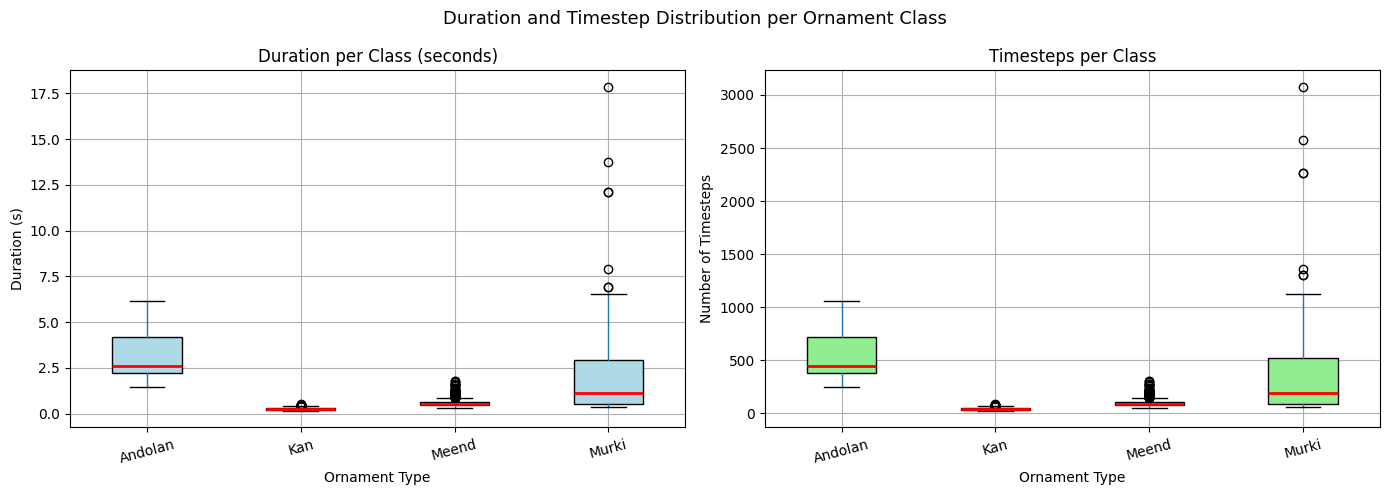

In [10]:
# Build dataframe from segments
df_segments = pd.DataFrame([{k: v for k, v in s.items() if k != "pitch_curve"} for s in segments])
df_segments['num_timesteps'] = [len(s['pitch_curve']) for s in segments]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Duration boxplot
df_segments.boxplot(column='duration', by='label', ax=axes[0], 
                    patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='red', linewidth=2))
axes[0].set_title("Duration per Class (seconds)")
axes[0].set_xlabel("Ornament Type")
axes[0].set_ylabel("Duration (s)")
plt.sca(axes[0])
plt.xticks(rotation=15)

# Timesteps boxplot
df_segments.boxplot(column='num_timesteps', by='label', ax=axes[1],
                    patch_artist=True,
                    boxprops=dict(facecolor='lightgreen'),
                    medianprops=dict(color='red', linewidth=2))
axes[1].set_title("Timesteps per Class")
axes[1].set_xlabel("Ornament Type")
axes[1].set_ylabel("Number of Timesteps")
plt.sca(axes[1])
plt.xticks(rotation=15)

plt.suptitle("")  # remove auto title from boxplot
fig.suptitle("Duration and Timestep Distribution per Ornament Class", fontsize=13)
plt.tight_layout()
plt.show()

### Model

In [13]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

### Data preprocess

In [24]:
def prepare_tcn_input(segments, fixed_length=200):
    """
    Takes raw segments from extract_ornament_segments and prepares
    fixed-length numpy arrays for TCN training.
    """
    label_map = {"Kan": 0, "Meend": 1, "Murki": 2}
    
    X, y = [], []
    skipped = 0

    # Filter too-short segments before processing
    segments = [s for s in segments if len(s['pitch_curve']) >= 20]
    
    for seg in segments:
        curve = seg['pitch_curve']
        label = seg['label']
        
        if label not in label_map:
            skipped += 1
            continue
        
        # Normalize each curve to zero mean and unit variance
        if curve.std() > 0:
            curve = (curve - curve.mean()) / curve.std()
        
        # Pad to fixed length
        if len(curve) < fixed_length:
            curve = np.pad(curve, (0, fixed_length - len(curve)), mode='constant')
        else:
            curve = curve[:fixed_length]
        
        X.append(curve)
        y.append(label_map[label])
    
    X = np.array(X, dtype=np.float32)[:, np.newaxis, :]  # (N, 1, fixed_length)
    y = np.array(y, dtype=np.int64)
    
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    print(f"Skipped: {skipped}")
    print(f"Label distribution: { {k: int((y==v).sum()) for k,v in label_map.items()} }")
    
    return X, y, label_map


def get_dataloaders(X_train, y_train, X_test, y_test, batch_size=16):

    train_ds = TensorDataset(
        torch.tensor(X_train),
        torch.tensor(y_train)
    )

    test_ds = TensorDataset(
        torch.tensor(X_test),
        torch.tensor(y_test)
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False
    )

    print(f"Train samples: {len(train_ds)}")
    print(f"Test samples: {len(test_ds)}")

    return train_loader, test_loader

In [25]:
train_segments = [s for s in segments if s["split"] == "train"]
test_segments  = [s for s in segments if s["split"] == "test"]

X_train, y_train, label_map = prepare_tcn_input(train_segments)
X_test, y_test, _ = prepare_tcn_input(test_segments)

train_loader, test_loader = get_dataloaders(X_train, y_train, X_test, y_test)

X shape: (1529, 1, 200)
y shape: (1529,)
Skipped: 0
Label distribution: {'Kan': 750, 'Meend': 662, 'Murki': 117}
X shape: (511, 1, 200)
y shape: (511,)
Skipped: 0
Label distribution: {'Kan': 239, 'Meend': 224, 'Murki': 48}
Train samples: 1529
Test samples: 511


### Train

In [26]:
class ResidualBlock(nn.Module):
    def __init__(self, channels, kernel_size, dilation):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, dilation=dilation, padding=padding)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size, dilation=dilation, padding=padding)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.norm1 = nn.BatchNorm1d(channels)
        self.norm2 = nn.BatchNorm1d(channels)

    def forward(self, x):
        out = self.relu(self.norm1(self.conv1(x)[:, :, :x.size(2)]))
        out = self.dropout(out)
        out = self.relu(self.norm2(self.conv2(out)[:, :, :x.size(2)]))
        return self.relu(out + x)  # residual connection


class OrnamentTCN(nn.Module):
    def __init__(self, input_size=1, num_classes=4, channels=32, kernel_size=3):
        super().__init__()
        self.input_proj = nn.Conv1d(input_size, channels, kernel_size=1)
        self.tcn = nn.Sequential(
            ResidualBlock(channels, kernel_size, dilation=1),
            ResidualBlock(channels, kernel_size, dilation=2),
            ResidualBlock(channels, kernel_size, dilation=4),
            ResidualBlock(channels, kernel_size, dilation=8),
            ResidualBlock(channels, kernel_size, dilation=16),  
            ResidualBlock(channels, kernel_size, dilation=32), 
        )
        self.classifier = nn.Linear(channels, num_classes)

    def forward(self, x):
        out = self.input_proj(x)
        out = self.tcn(out)
        out = out.mean(dim=2)  # global average pooling
        return self.classifier(out)

In [27]:
class TemporalPyramidPool(nn.Module):
    def __init__(self, levels=[1, 2, 4]):
        """
        levels: number of bins at each pyramid level
        e.g. [1, 2, 4] → pools to 1, 2, and 4 segments
        total output size = channels * sum(levels) = channels * 7
        """
        super().__init__()
        self.levels = levels
    
    def forward(self, x):
        # x: (batch, channels, time)
        pooled = []
        for level in self.levels:
            # AdaptiveAvgPool1d handles any input length
            pool = nn.AdaptiveAvgPool1d(level)(x)   # (batch, channels, level)
            pooled.append(pool.flatten(1))           # (batch, channels * level)
        return torch.cat(pooled, dim=1)              # (batch, channels * sum(levels))


class OrnamentTCN_TempPyr(nn.Module):
    def __init__(self, input_size=1, num_classes=3, channels=32, 
                 kernel_size=3, pyramid_levels=[1, 2, 4]):
        super().__init__()
        self.input_proj = nn.Conv1d(input_size, channels, kernel_size=1)
        self.tcn = nn.Sequential(
            ResidualBlock(channels, kernel_size, dilation=1),
            ResidualBlock(channels, kernel_size, dilation=2),
            ResidualBlock(channels, kernel_size, dilation=4),
            ResidualBlock(channels, kernel_size, dilation=8),
            ResidualBlock(channels, kernel_size, dilation=16),
            ResidualBlock(channels, kernel_size, dilation=32),
        )
        self.tpp = TemporalPyramidPool(levels=pyramid_levels)
        
        # Output size = channels * sum(pyramid_levels)
        tpp_output_size = channels * sum(pyramid_levels)
        self.classifier = nn.Linear(tpp_output_size, num_classes)

    def forward(self, x):
        out = self.input_proj(x)
        out = self.tcn(out)
        out = self.tpp(out)          # (batch, channels * sum(levels))
        return self.classifier(out)

In [18]:
def train_tcn(train_loader, test_loader, model, checkpoint_name="tcn", num_classes=4, epochs=30, checkpoint_dir="checkpoints"):
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    # Handle both TensorDataset and custom Dataset
    try:
        all_labels = train_loader.dataset.tensors[1].numpy()
    except AttributeError:
        all_labels = train_loader.dataset.y.numpy()
        
    weights = compute_class_weight('balanced', classes=np.unique(all_labels), y=all_labels)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float))
    
    best_test_acc = 0.0
    
    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0
        for batch in train_loader:
            xb, yb = batch[0], batch[1]  # works for (xb,yb) and (xb,yb,lengths)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            correct += (preds.argmax(1) == yb).sum().item()
            total += len(yb)

        model.eval()
        test_correct, test_total = 0, 0
        with torch.no_grad():
            for batch in test_loader:
                xb, yb = batch[0], batch[1]
                preds = model(xb)
                test_correct += (preds.argmax(1) == yb).sum().item()
                test_total += len(yb)
                
        test_acc = test_correct / test_total
        print(f"Epoch {epoch+1:02d} | Loss: {train_loss/len(train_loader):.4f} | Train Acc: {correct/total:.3f} | Test Acc: {test_acc:.3f}")
        
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'test_acc': test_acc,
        }
        torch.save(checkpoint, os.path.join(checkpoint_dir, f"{checkpoint_name}_latest.pth"))
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            torch.save(checkpoint, os.path.join(checkpoint_dir, f"{checkpoint_name}_best.pth"))
            print(f"  -> New best Test Acc: {best_test_acc:.3f}")
    
    return model


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score,classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
# After running extract_ornament_segments
#X, y, label_map = prepare_tcn_input(segments_aug, fixed_length=200)
#train_loader, test_loader = get_dataloaders(X, y, batch_size=16)
#model = train_tcn(train_loader, test_loader, epochs=30, checkpoint_dir="checkpoints_temp")
model = train_tcn(train_loader, test_loader, model=OrnamentTCN_TempPyr(input_size=1, num_classes=3), checkpoint_name="TPP_aug")

Epoch 01 | Loss: 0.5354 | Train Acc: 0.842 | Test Acc: 0.896
  -> New best Test Acc: 0.896
Epoch 02 | Loss: 0.2914 | Train Acc: 0.922 | Test Acc: 0.910
  -> New best Test Acc: 0.910
Epoch 03 | Loss: 0.2438 | Train Acc: 0.937 | Test Acc: 0.924
  -> New best Test Acc: 0.924
Epoch 04 | Loss: 0.1760 | Train Acc: 0.948 | Test Acc: 0.939
  -> New best Test Acc: 0.939
Epoch 05 | Loss: 0.1575 | Train Acc: 0.947 | Test Acc: 0.937
Epoch 06 | Loss: 0.1572 | Train Acc: 0.956 | Test Acc: 0.941
  -> New best Test Acc: 0.941
Epoch 07 | Loss: 0.1740 | Train Acc: 0.948 | Test Acc: 0.953
  -> New best Test Acc: 0.953
Epoch 08 | Loss: 0.1510 | Train Acc: 0.954 | Test Acc: 0.955
  -> New best Test Acc: 0.955
Epoch 09 | Loss: 0.1029 | Train Acc: 0.970 | Test Acc: 0.961
  -> New best Test Acc: 0.961
Epoch 10 | Loss: 0.0883 | Train Acc: 0.974 | Test Acc: 0.967
  -> New best Test Acc: 0.967
Epoch 11 | Loss: 0.1160 | Train Acc: 0.961 | Test Acc: 0.943
Epoch 12 | Loss: 0.1073 | Train Acc: 0.965 | Test Acc: 0.96

In [30]:
def evaluate_model(model, test_loader, label_map):
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for xb, yb in test_loader:
            preds = model(xb).argmax(1)
            all_preds.extend(preds.numpy())
            all_labels.extend(yb.numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    idx_to_label = {v: k for k, v in label_map.items()}
    target_names = [idx_to_label[i] for i in range(len(label_map))]
    
    # Classification report
    print("=== Classification Report ===")
    print(classification_report(all_labels, all_preds, target_names=target_names))
    
    # Explicit per-class metrics
    precision = precision_score(all_labels, all_preds, average=None)
    recall    = recall_score(all_labels, all_preds, average=None)
    f1        = f1_score(all_labels, all_preds, average=None)
    
    print("=== Per-class Metrics ===")
    for i, name in enumerate(target_names):
        print(f"{name:10s} | Precision: {precision[i]:.3f} | Recall: {recall[i]:.3f} | F1: {f1[i]:.3f}")
    
    # Macro averages
    print(f"\n{'Macro avg':10s} | Precision: {precision.mean():.3f} | Recall: {recall.mean():.3f} | F1: {f1.mean():.3f}")
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names,
                yticklabels=target_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()
    
    return all_preds, all_labels, precision, recall, f1

=== Classification Report ===
              precision    recall  f1-score   support

         Kan       0.96      1.00      0.98       239
       Meend       0.96      0.99      0.98       224
       Murki       0.97      0.62      0.76        48

    accuracy                           0.96       511
   macro avg       0.96      0.87      0.90       511
weighted avg       0.96      0.96      0.96       511

=== Per-class Metrics ===
Kan        | Precision: 0.960 | Recall: 1.000 | F1: 0.980
Meend      | Precision: 0.961 | Recall: 0.991 | F1: 0.976
Murki      | Precision: 0.968 | Recall: 0.625 | F1: 0.759

Macro avg  | Precision: 0.963 | Recall: 0.872 | F1: 0.905


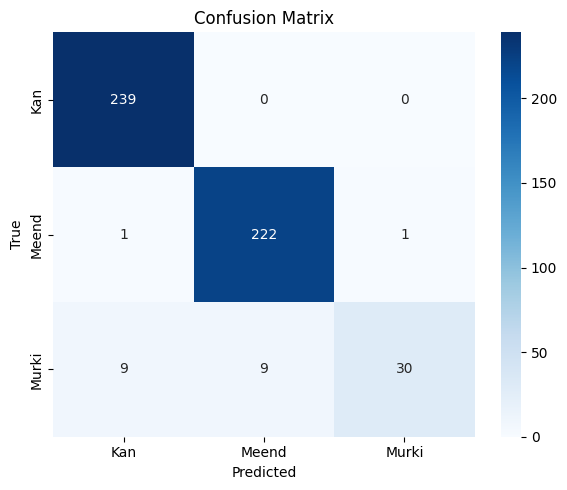

Precision: [0.95983936 0.96103896 0.96774194]
Recall:    [1.         0.99107143 0.625     ]
F1:        [0.9795082  0.97582418 0.75949367]


In [31]:
all_preds, all_labels, precision, recall, f1 = evaluate_model(model, test_loader, label_map)

# Print as arrays
print("Precision:", precision)
print("Recall:   ", recall)
print("F1:       ", f1)